In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
from QNeuralForecast.patchtst import QPatchTST
from QNeuralForecast.timesnet import QTimesNet
from QNeuralForecast.nhits import QNHITS
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet

from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.tensorboard import SummaryWriter
from neuralforecast.losses.numpy import mae, mse, rmse, mape, smape, mase

In [105]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)
df = df.sort_values(["Store","Date"])

split_date = "2015-01-01"

train_df = df[df["Date"] < split_date].copy()
test_df  = df[df["Date"] >= split_date].copy()  # held-out test set, never used for tuning


In [ ]:
HORIZON=100
INPUT_SIZE=400
#OPTIMIZER=Adam() # <-- TODO: specify list of params
MAX_STEPS=100
SCALER_TYPE="standard"

#models_classes = [DLinear, QDLinear, NHITS, QNHITS, PatchTST, QPatchTST, TimesNet, QTimesNet]
models_classes = [DLinear,QDLinear]
models = []

for model_class in models_classes:
    model_name = model_class.__name__
    models.append(
        model_class(
            h=HORIZON,
            input_size=INPUT_SIZE,
            max_steps=MAX_STEPS,
            scaler_type=SCALER_TYPE,
            start_padding_enabled=True,
            **{"logger": TensorBoardLogger("lightning_logs", name=model_name, prefix="kfold_")},
        )
    )

In [107]:
nf = NeuralForecast(models=models, freq="D")

In [ ]:
# Cross-validation for model selection (refit=False: faster, avoids unreliable refit behaviour)
cv_df = nf.cross_validation(
    train_df, n_windows=4, step_size=100,
    verbose=False, refit=1,
    id_col="Store", time_col="Date", target_col="Sales"
)

# Explicitly refit on the full train_df so nf.predict() starts from the correct date.
nf.fit(train_df, id_col="Store", time_col="Date", target_col="Sales")


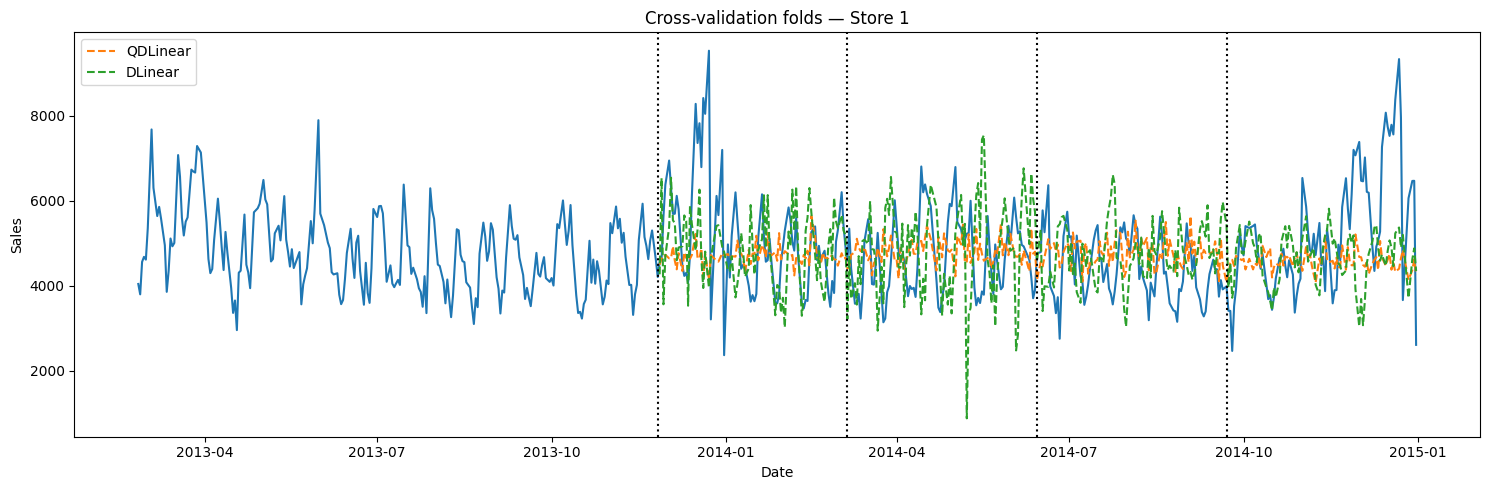

Cross-validation metrics (aggregated over all folds & stores):
  DLinear: MAE=1897.7434
  QDLinear: MAE=1606.9570


In [115]:
# --- CV visualization (store 1) ---
df1 = train_df[train_df["Store"] == 1]
cv_df1 = cv_df[cv_df['Store'] == 1]

cutoffs = cv_df1['cutoff'].unique()

plt.figure(figsize=(15, 5))
plt.plot(df1['Date'], df1['Sales'])
plt.plot(cv_df1['Date'], cv_df1['QDLinear'], label='QDLinear', ls='--')
plt.plot(cv_df1['Date'], cv_df1['DLinear'],  label='DLinear',  ls='--')
for cutoff in cutoffs:
    plt.axvline(x=cutoff, color='black', ls=':')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Cross-validation folds — Store 1')
plt.legend()
plt.tight_layout()
plt.show()

# --- CV-level metrics (model selection signal) ---
print("Cross-validation metrics (aggregated over all folds & stores):")
model_names=[c for c in cv_df.columns if c not in ["Store", "Date", "Sales", "cutoff"]]
for model in model_names:
    cv_mae = mae(cv_df["Sales"].values, cv_df[model].values)
    print(f"  {model}: MAE={cv_mae:.4f}")


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Forecast date range: 2014-07-01 00:00:00 → 2015-04-10 00:00:00
Test    date range:  2015-01-01 00:00:00 → 2015-07-31 00:00:00
Matched rows after merge: 77738
Models found: ['DLinear', 'QDLinear']
  [DLinear] test metrics logged to TensorBoard.
  [QDLinear] test metrics logged to TensorBoard.

Test-set metrics per model:
  QDLinear: MAE=1492.3283  MSE=3998452.9273  RMSE=1999.6132  MAPE=0.2389  MASE=0.6279
  DLinear: MAE=2076.8723  MSE=7715756.6621  RMSE=2777.7251  MAPE=0.3170  MASE=0.8738

Top 5 Stores (best predicted on average): [794, 789, 656, 558, 958]


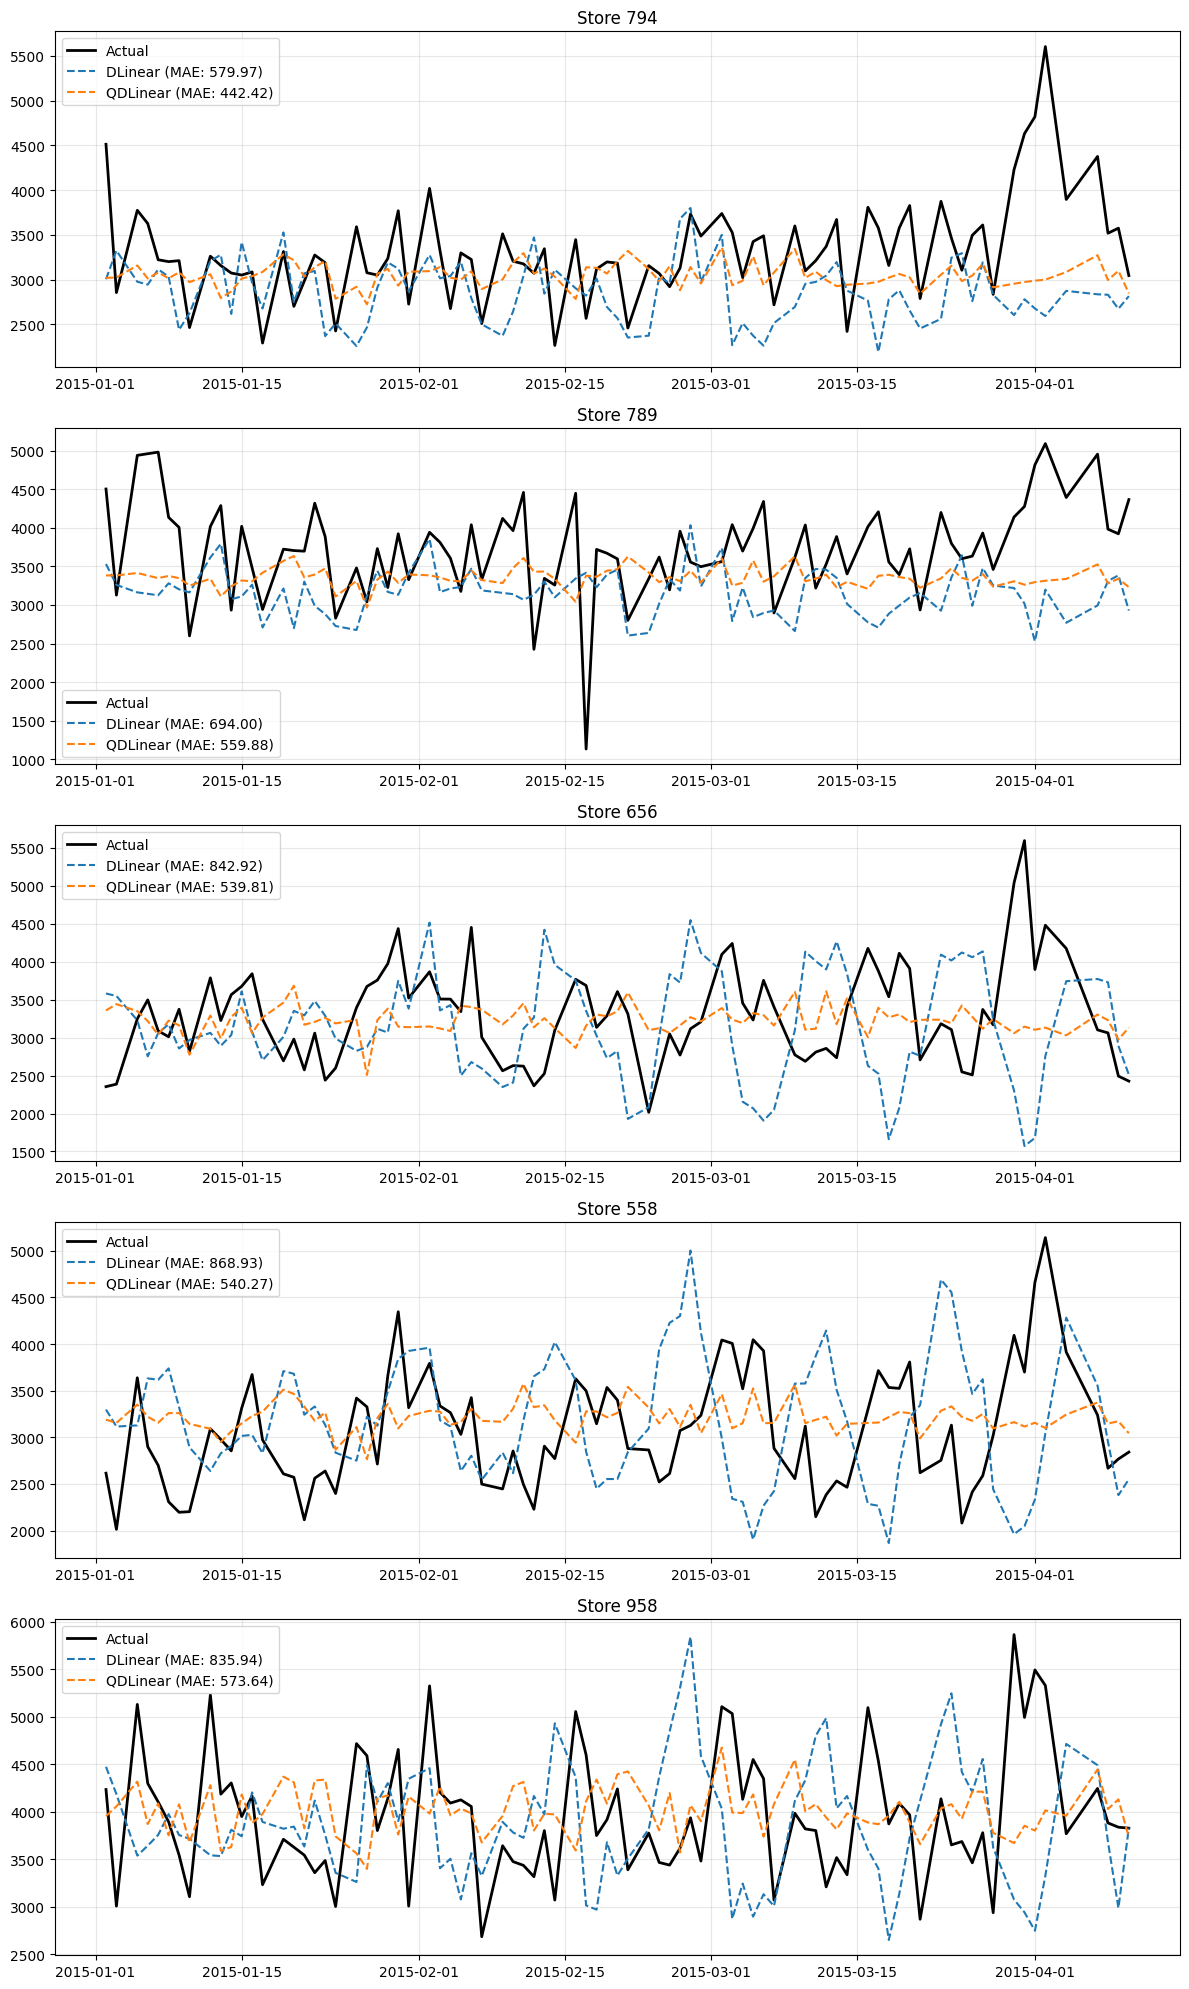

In [116]:
# --- Final test-set evaluation ---
# nf.fit() was called on the full train_df, so predict() starts from 2015-01-01.
forecasts = nf.predict().reset_index()
print("Forecast date range:", forecasts["Date"].min(), "→", forecasts["Date"].max())
print("Test    date range: ", test_df["Date"].min(),  "→", test_df["Date"].max())

comparison = test_df[["Store", "Date", "Sales"]].merge(forecasts, on=["Store", "Date"], how="inner")
print(f"Matched rows after merge: {len(comparison)}")

model_names = [col for col in forecasts.columns if col not in ["index", "Store", "Date"]]
print(f"Models found: {model_names}")

# y_train for MASE baseline (weekly seasonality for daily data)
y_train_global = train_df["Sales"].values
SEASONALITY = 7

# Calculate metrics and log to TensorBoard
results = {}
for model in model_names:
    model_MAE  = mae( comparison["Sales"], comparison[model])
    model_MSE  = mse( comparison["Sales"], comparison[model])
    model_RMSE = rmse(comparison["Sales"], comparison[model])
    model_MAPE = mape(comparison["Sales"], comparison[model])
    model_MASE = mase(comparison["Sales"], comparison[model],
                      y_train=y_train_global, seasonality=SEASONALITY)
    results[model] = {"MAE": model_MAE, "MSE": model_MSE,
                      "RMSE": model_RMSE, "MAPE": model_MAPE, "MASE": model_MASE}

    writer = SummaryWriter(log_dir=f"lightning_logs/{model}/test_metrics")
    for metric_name, val in results[model].items():
        writer.add_scalar(f"test/{metric_name}", val, 0)
    writer.close()
    print(f"  [{model}] test metrics logged to TensorBoard.")

print("\nTest-set metrics per model:")
for m, scores in sorted(results.items(), key=lambda x: x[1]["MAE"]):
    print(f"  {m}: MAE={scores['MAE']:.4f}  MSE={scores['MSE']:.4f}  "
          f"RMSE={scores['RMSE']:.4f}  MAPE={scores['MAPE']:.4f}  MASE={scores['MASE']:.4f}")

# Top 5 best-predicted stores
comparison["avg_model_error"] = sum(
    (comparison["Sales"] - comparison[m]).abs() for m in model_names
) / len(model_names)

top_5_stores = (comparison.groupby("Store")["avg_model_error"]
                           .mean().sort_values().head(5).index.tolist())
print(f"\nTop 5 Stores (best predicted on average): {top_5_stores}")

# Plot
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=False)
for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    ax = axes[i]
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual", color='black', linewidth=2)
    for model in model_names:
        store_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model],
                label=f"{model} (MAE: {store_mae:.2f})", linestyle='--')
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
